In [ ]:
# -*- coding: utf-8 -*-
"""
Utility: print example prompts from generated JSON files (prompts/).
- For each of the target days [0, 20, 40, 60, 80, 100, 120], if a JSON exists,
  randomly sample one entry from patients and caregivers and print the full prompt.
- You can also call `print_one(file_path, pid=None)` to print a specific file (and optional participant id).

Run in a Jupyter notebook cell.
"""

import json
import random
from pathlib import Path
from typing import Optional, Dict
from huggingface_hub import snapshot_download

# ---------- Config ----------
HF_REPO_ID = "nichenshun/rdmap_prompts_pre7days_activity"  
HF_CACHE_DIR = Path("./hf_cache")  

PROMPTS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

TARGET_DAYS = [0, 20, 40, 60, 80, 100, 120]
ROLES = ["patients", "caregivers"]
SEED = 2025  # for reproducibility of random sampling
random.seed(SEED)

def load_json(path: Path) -> Optional[Dict[str, str]]:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError(f"JSON at {path} is not a dict of id -> prompt.")
    return data

def print_divider(title: str = "", char: str = "=", width: int = 100):
    line = char * width
    if title:
        print(f"\n{line}\n{title}\n{line}")
    else:
        print(f"\n{line}")

def print_one(file_path: Path, pid: Optional[str] = None):
    """
    Print one prompt from a given file.
    - If pid is None, randomly pick one id
    - If pid is provided but not found, raise KeyError
    """
    data = load_json(file_path)
    if data is None:
        print(f"[WARN] File not found: {file_path}")
        return

    if not data:
        print(f"[WARN] File exists but empty: {file_path}")
        return

    if pid is None:
        pid = random.choice(list(data.keys()))
    elif pid not in data:
        raise KeyError(f"pid {pid} not found in {file_path}")

    prompt = data[pid]
    print_divider(f"FILE: {file_path.name} | PID: {pid}")
    print(prompt)

def print_random_examples(prompts_dir: Path = PROMPTS_DIR,
                          roles = ROLES,
                          target_days = TARGET_DAYS,
                          sample_per_file: int = 1):
    """
    For each role/day file that exists, print `sample_per_file` random prompts.
    """
    for role in roles:
        for day in target_days:
            file_path = prompts_dir / f"{role}_day{day}.json"
            data = load_json(file_path)
            if data is None:
                # File missing, skip quietly
                continue
            if not data:
                print(f"[WARN] Empty JSON: {file_path}")
                continue

            ids = list(data.keys())
            # If the file has fewer than requested, adjust
            k = min(sample_per_file, len(ids))
            picked = random.sample(ids, k=k)
            for pid in picked:
                print_divider(f"FILE: {file_path.name} | PID: {pid}")
                print(data[pid])

# ---------- Usage examples ----------

# 1) Print one random example per available role/day file:
print_random_examples(sample_per_file=1)

# 2) (Optional) Print one specific file with random id:
# print_one(PROMPTS_DIR / "patients_day20.json")

# 3) (Optional) Print one specific participant from a file:
# print_one(PROMPTS_DIR / "patients_day20.json", pid="P094")


Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 13955.17it/s]


FILE: patients_day0.json | PID: P115
You are a patient participant in a dyad in the ROADMAP 2.0 mobile-health study. 

You are a patient recovering from a hematopoietic cell transplantation (HCT) to treat a blood-related disease such as leukemia or lymphoma. During recovery, you may experience fatigue, nausea, pain, sleep disturbances, and emotional stress, while relying on your care partner and medical team to help you regain strength and prevent complications like infections or graft-versus-host disease. 

Each day, you are asked to enter your mood on a 1-10 scale (1=worst, 10=best). 

The study seeks to understand links between sensor data and well-being and to support caregivers during and after transplant. 

Each time step in this simulation represents one day.


- **Your Background:**
- You are in the 18-39 age group.
- Your gender is male.
- You are assigned to the Intervention arm of the study.
- Your transplant type is Autologous.
- You stayed in the hospital for 14 days.
- Y

Fetching 16 files: 100%|██████████| 16/16 [00:00<00:00, 31.53it/s]


[INFO] patients day 0: TP=8, FP=19, TN=44, FN=29, TPR=0.216 FPR=0.302 ACC=0.520 CE=0.793
[INFO] patients day 20: TP=26, FP=8, TN=56, FN=10, TPR=0.722 FPR=0.125 ACC=0.820 CE=0.463
[INFO] patients day 40: TP=30, FP=15, TN=49, FN=6, TPR=0.833 FPR=0.234 ACC=0.790 CE=0.449
[INFO] patients day 60: TP=28, FP=12, TN=52, FN=8, TPR=0.778 FPR=0.188 ACC=0.800 CE=0.452
[INFO] patients day 80: TP=25, FP=12, TN=59, FN=4, TPR=0.862 FPR=0.169 ACC=0.840 CE=0.414
[INFO] patients day 100: TP=27, FP=8, TN=62, FN=3, TPR=0.900 FPR=0.114 ACC=0.890 CE=0.346
[INFO] patients day 120: TP=24, FP=7, TN=63, FN=6, TPR=0.800 FPR=0.100 ACC=0.870 CE=0.392
[INFO] caregivers day 0: TP=45, FP=41, TN=6, FN=8, TPR=0.849 FPR=0.872 ACC=0.510 CE=0.835
[INFO] caregivers day 20: TP=50, FP=14, TN=29, FN=7, TPR=0.877 FPR=0.326 ACC=0.790 CE=0.540
[INFO] caregivers day 40: TP=58, FP=5, TN=34, FN=2, TPR=0.967 FPR=0.128 ACC=0.929 CE=0.308
[INFO] caregivers day 60: TP=43, FP=15, TN=37, FN=5, TPR=0.896 FPR=0.288 ACC=0.800 CE=0.467
[INFO]

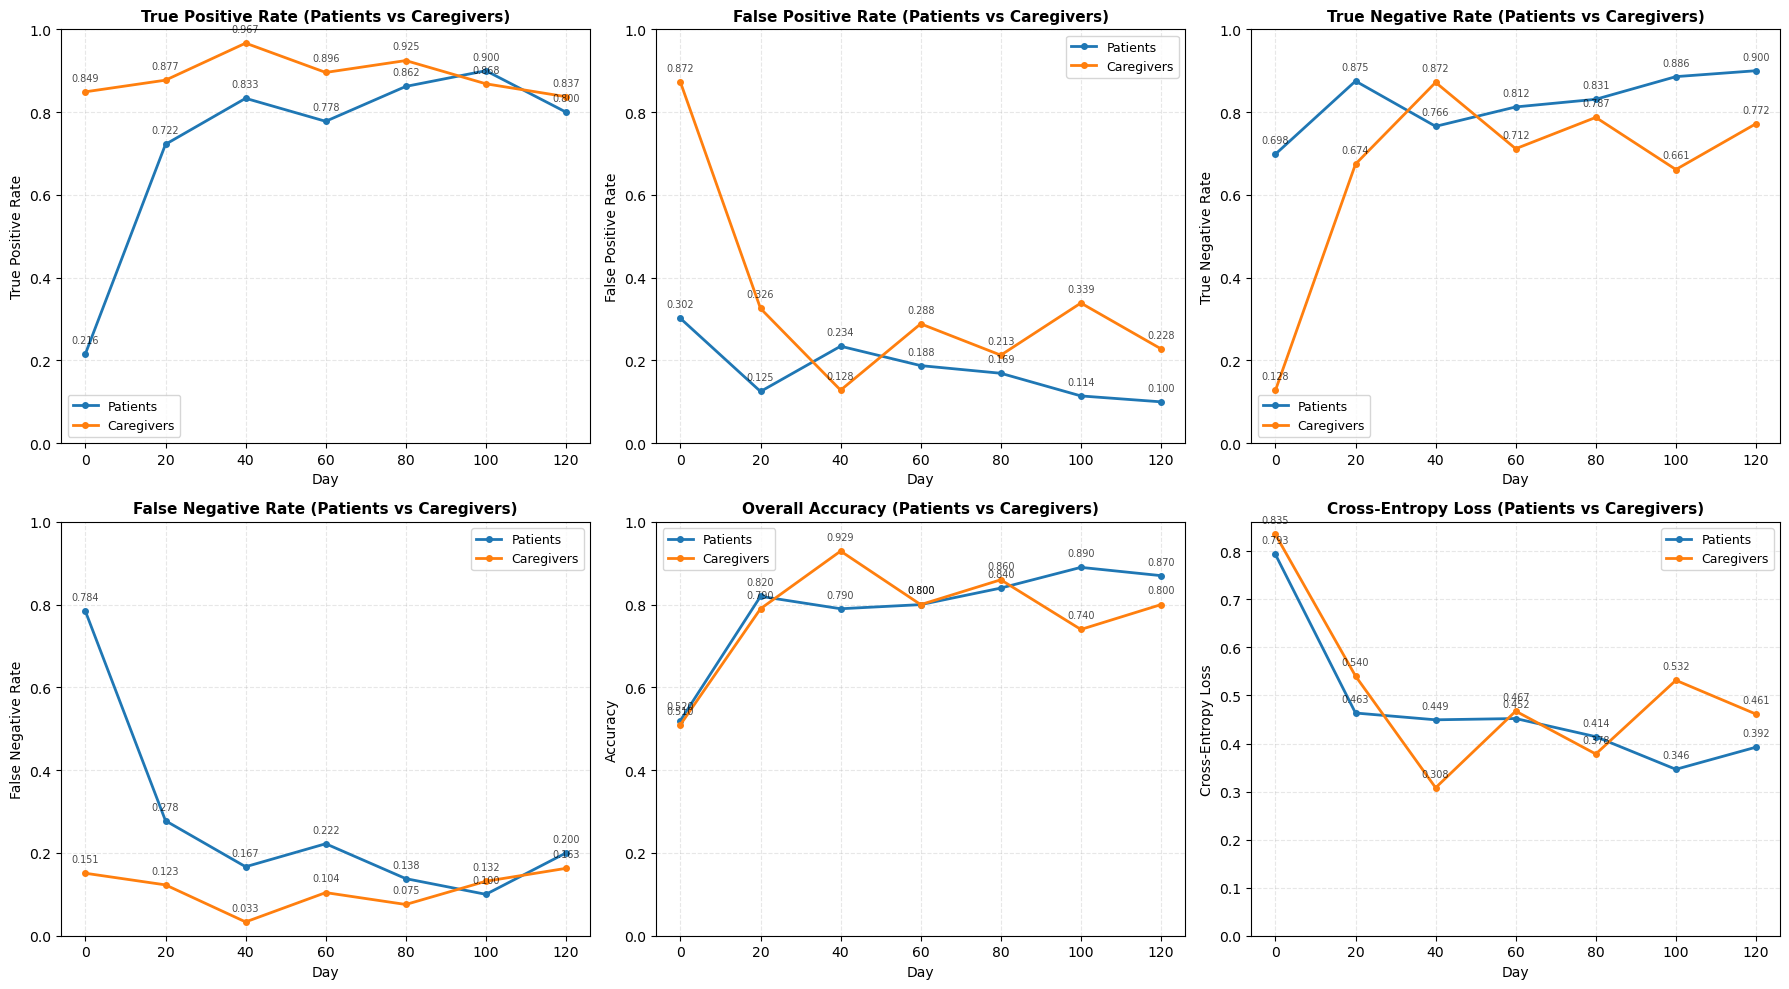


SUMMARY STATISTICS BY ROLE

Patients:
----------------------------------------
  True Positive Rate: 0.730 ± 0.217
  False Positive Rate: 0.176 ± 0.067
  True Negative Rate: 0.824 ± 0.067
  False Negative Rate: 0.270 ± 0.217
  Accuracy: 0.790 ± 0.115
  Cross-Entropy: 0.473 ± 0.136

Caregivers:
----------------------------------------
  True Positive Rate: 0.888 ± 0.042
  False Positive Rate: 0.342 ± 0.227
  True Negative Rate: 0.658 ± 0.227
  False Negative Rate: 0.112 ± 0.042
  Accuracy: 0.776 ± 0.122
  Cross-Entropy: 0.503 ± 0.155


In [ ]:
import json
from pathlib import Path
from typing import Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from huggingface_hub import snapshot_download

# --------------------
# Config
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
HF_REPO_ID = "nichenshun/rdmap_predictions_pre7days_activity"  
HF_CACHE_DIR = Path("./hf_cache")  

PREDICTIONS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

ROLES = ["patients", "caregivers"]
DAYS = [0, 20, 40, 60, 80, 100, 120]

# --------------------
# Load participants_data.json
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_data.json must be a dict keyed by participant ID.")

# --------------------
# Helper: get ground-truth label for (pid, day)
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

# --------------------
# Helper: extract decision and confidence
# --------------------
def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

# --------------------
# Aggregate metrics storage
# --------------------
metrics = {
    role: {
        "tpr": [],
        "fpr": [],
        "tnr": [],
        "fnr": [],
        "acc": [],
        "ce":  [],
    }
    for role in ROLES
}

# Store detailed data for printing
detailed_data = []

# --------------------
# Main loop: per role × day, compute metrics
# --------------------
for role in ROLES:
    for day in DAYS:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            print(f"[WARN] Missing predictions file: {pred_file}. Metrics will be NaN for {role}, day {day}.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            print(f"[WARN] Predictions file {pred_file} is not a dict. Metrics will be NaN.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            continue

        # Counters
        TP = FP = TN = FN = 0
        ce_losses = []

        for pid, rec in preds_dict.items():
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]
            conf = info["confidence"]
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Update confusion matrix
            if y_true == 1 and y_hat == 1:
                TP += 1
            elif y_true == 0 and y_hat == 1:
                FP += 1
            elif y_true == 0 and y_hat == 0:
                TN += 1
            elif y_true == 1 and y_hat == 0:
                FN += 1

            # Cross-entropy calculation
            if y_hat == 1:
                p_yes = conf
            else:
                p_yes = 1.0 - conf

            p_yes = max(1e-6, min(1.0 - 1e-6, p_yes))
            ce = -(y_true * np.log(p_yes) + (1 - y_true) * np.log(1 - p_yes))
            ce_losses.append(ce)

        # Compute rates
        P = TP + FN
        N = TN + FP
        total = P + N

        tpr = TP / P if P > 0 else np.nan
        fpr = FP / N if N > 0 else np.nan
        tnr = TN / N if N > 0 else np.nan
        fnr = FN / P if P > 0 else np.nan
        acc = (TP + TN) / total if total > 0 else np.nan
        ce_mean = float(np.mean(ce_losses)) if ce_losses else np.nan

        metrics[role]["tpr"].append(tpr)
        metrics[role]["fpr"].append(fpr)
        metrics[role]["tnr"].append(tnr)
        metrics[role]["fnr"].append(fnr)
        metrics[role]["acc"].append(acc)
        metrics[role]["ce"].append(ce_mean)

        # Store detailed data for printing
        detailed_data.append({
            'role': role,
            'day': day,
            'tpr': tpr,
            'fpr': fpr,
            'tnr': tnr,
            'fnr': fnr,
            'acc': acc,
            'ce': ce_mean,
            'TP': TP,
            'FP': FP,
            'TN': TN,
            'FN': FN,
            'total': total
        })

        print(f"[INFO] {role} day {day}: TP={TP}, FP={FP}, TN={TN}, FN={FN}, "
              f"TPR={tpr:.3f} FPR={fpr:.3f} ACC={acc:.3f} CE={ce_mean:.3f}")

# --------------------
# Print detailed point values
# --------------------
print("\n" + "="*100)
print("DETAILED METRIC VALUES FOR ALL POINTS")
print("="*100)

# Convert to DataFrame for easier printing
detailed_df = pd.DataFrame(detailed_data)

# Print table for each metric
metrics_to_print = ['tpr', 'fpr', 'tnr', 'fnr', 'acc', 'ce']
metric_names = {
    'tpr': 'True Positive Rate',
    'fpr': 'False Positive Rate', 
    'tnr': 'True Negative Rate',
    'fnr': 'False Negative Rate',
    'acc': 'Accuracy',
    'ce': 'Cross-Entropy'
}

for metric in metrics_to_print:
    print(f"\n{metric_names[metric].upper()}:")
    print("-" * 60)
    
    # Pivot table for better formatting
    pivot_data = detailed_df.pivot(index='day', columns='role', values=metric)
    
    # Print header
    header = f"{'Day':<4} {'Patients':<12} {'Caregivers':<12}"
    print(header)
    print("-" * len(header))
    
    # Print values for each day
    for day in DAYS:
        if day in pivot_data.index:
            patients_val = pivot_data.loc[day, 'patients'] if 'patients' in pivot_data.columns else np.nan
            caregivers_val = pivot_data.loc[day, 'caregivers'] if 'caregivers' in pivot_data.columns else np.nan
            
            patients_str = f"{patients_val:.3f}" if not np.isnan(patients_val) else "N/A"
            caregivers_str = f"{caregivers_val:.3f}" if not np.isnan(caregivers_val) else "N/A"
            
            print(f"{day:<4} {patients_str:<12} {caregivers_str:<12}")
        else:
            print(f"{day:<4} {'N/A':<12} {'N/A':<12}")

# --------------------
# Plot all metrics in 2x3 grid
# --------------------
def plot_all_metrics_grid(metrics):
    """Plot all 6 metrics in a 2x3 grid layout"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    metric_configs = [
        ("tpr", "True Positive Rate", "True Positive Rate (Patients vs Caregivers)"),
        ("fpr", "False Positive Rate", "False Positive Rate (Patients vs Caregivers)"),
        ("tnr", "True Negative Rate", "True Negative Rate (Patients vs Caregivers)"),
        ("fnr", "False Negative Rate", "False Negative Rate (Patients vs Caregivers)"),
        ("acc", "Accuracy", "Overall Accuracy (Patients vs Caregivers)"),
        ("ce", "Cross-Entropy Loss", "Cross-Entropy Loss (Patients vs Caregivers)")
    ]
    
    for i, (metric_key, ylabel, title) in enumerate(metric_configs):
        ax = axes[i]
        
        for role in ROLES:
            values = metrics[role][metric_key]
            ax.plot(DAYS, values, marker="o", linewidth=2, markersize=4, 
                   label=role.capitalize())
            
            # Add value annotations
            for j, (day, value) in enumerate(zip(DAYS, values)):
                if not np.isnan(value):
                    ax.annotate(f'{value:.3f}', 
                               (day, value),
                               textcoords="offset points",
                               xytext=(0,8),
                               ha='center',
                               fontsize=7,
                               alpha=0.7)
        
        ax.set_xlabel("Day", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_xticks(DAYS)
        
        # Set appropriate y-axis limits
        if metric_key == 'ce':
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Generate the grid plot
plot_all_metrics_grid(metrics)

# --------------------
# Print summary statistics
# --------------------
print("\n" + "="*80)
print("SUMMARY STATISTICS BY ROLE")
print("="*80)

for role in ROLES:
    print(f"\n{role.capitalize()}:")
    print("-" * 40)
    
    for metric in metrics_to_print:
        values = [v for v in metrics[role][metric] if not np.isnan(v)]
        if values:
            mean_val = np.mean(values)
            std_val = np.std(values)
            print(f"  {metric_names[metric]}: {mean_val:.3f} ± {std_val:.3f}")
        else:
            print(f"  {metric_names[metric]}: No valid data")

Fetching 16 files: 100%|██████████| 16/16 [00:00<00:00, 12434.48it/s]


DETAILED ACCURACY VALUES FOR EACH DEMOGRAPHIC GROUP

ARM DETAILED VALUES:
Day  Control     Intervention
-----------------------------
0    0.520 (98)  0.510 (102) 
20   0.827 (98)  0.784 (102) 
40   0.847 (98)  0.871 (101) 
60   0.776 (98)  0.824 (102) 
80   0.837 (98)  0.863 (102) 
100  0.755 (98)  0.873 (102) 
120  0.847 (98)  0.824 (102) 

GENDER DETAILED VALUES:
Day  Female      Male        
-----------------------------
0    0.575 (106) 0.447 (94)  
20   0.783 (106) 0.830 (94)  
40   0.895 (105) 0.819 (94)  
60   0.792 (106) 0.809 (94)  
80   0.868 (106) 0.830 (94)  
100  0.755 (106) 0.883 (94)  
120  0.783 (106) 0.894 (94)  

TRANSPLANT_TYPE DETAILED VALUES:
Day  Allogeneic  Autologous  
-----------------------------
0    0.556 (124) 0.447 (76)  
20   0.839 (124) 0.750 (76)  
40   0.878 (123) 0.829 (76)  
60   0.823 (124) 0.763 (76)  
80   0.887 (124) 0.789 (76)  
100  0.815 (124) 0.816 (76)  
120  0.839 (124) 0.829 (76)  

ROLE DETAILED VALUES:
Day  Caregivers  Patients    
----

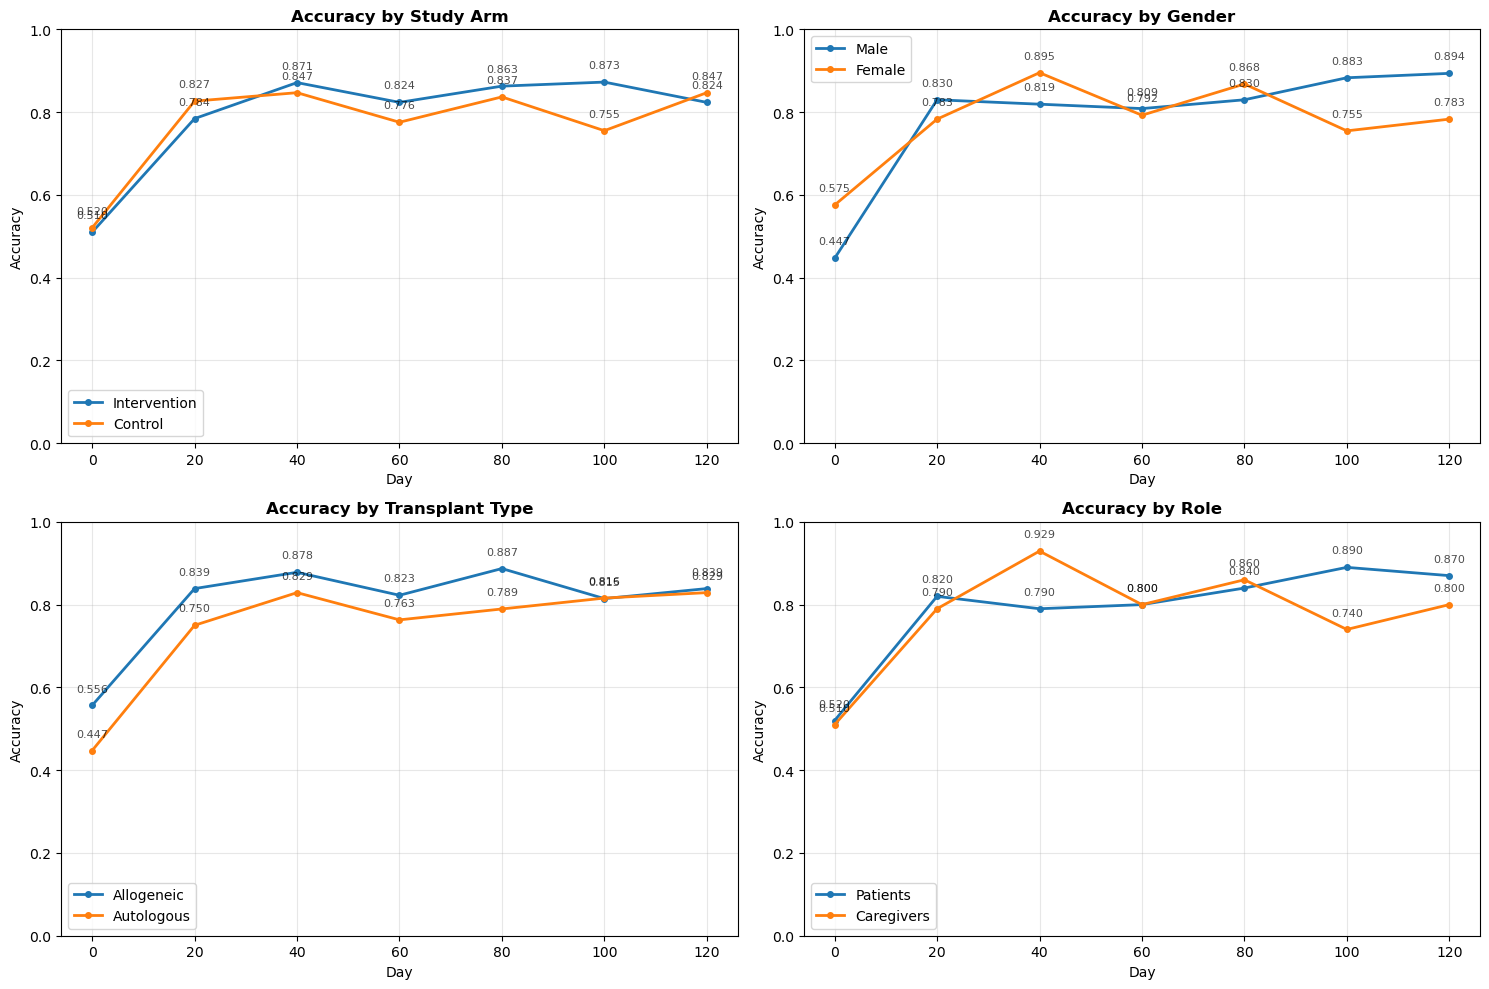


OVERALL ACCURACY SUMMARY BY DEMOGRAPHIC GROUPS

ARM ANALYSIS:
----------------------------------------
  Intervention: 0.793 ± 0.129 (n=713)
  Control: 0.773 ± 0.117 (n=686)

GENDER ANALYSIS:
----------------------------------------
  Male: 0.787 ± 0.154 (n=658)
  Female: 0.779 ± 0.103 (n=741)

TRANSPLANT_TYPE ANALYSIS:
----------------------------------------
  Allogeneic: 0.805 ± 0.113 (n=867)
  Autologous: 0.746 ± 0.135 (n=532)

ROLE ANALYSIS:
----------------------------------------
  Patients: 0.790 ± 0.124 (n=700)
  Caregivers: 0.776 ± 0.132 (n=699)


In [11]:
import json
from pathlib import Path
from typing import Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from huggingface_hub import snapshot_download


# --------------------
# Config
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
HF_REPO_ID = "nichenshun/rdmap_predictions_pre7days_activity"  
HF_CACHE_DIR = Path("./hf_cache")  

PREDICTIONS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

ROLES = ["patients", "caregivers"]
DAYS = [0, 20, 40, 60, 80, 100, 120]

# --------------------
# Load participants_data.json
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_data.json must be a dict keyed by participant ID.")

# --------------------
# Helper: get ground-truth label for (pid, day)
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

# --------------------
# Helper: extract decision and confidence
# --------------------
def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

# --------------------
# Get demographic information
# --------------------
def get_demographic_info(pid: str) -> Dict[str, str]:
    """Extract demographic information for a participant"""
    node = participants.get(pid, {})
    demo = node.get("Demographic", {}) or {}
    
    return {
        "arm": demo.get("arm", "Unknown"),
        "gender": demo.get("gender", "Unknown"), 
        "transplant_type": demo.get("transplant_type", "Unknown"),
        "role": demo.get("role", "Unknown")
    }

# --------------------
# Main analysis: compute accuracy by demographic groups
# --------------------
demographic_metrics = {
    "arm": {},
    "gender": {},
    "transplant_type": {},
    "role": {}
}

# Initialize structure for each demographic category
for category in demographic_metrics:
    demographic_metrics[category] = {}
    for day in DAYS:
        demographic_metrics[category][day] = {}

# Process predictions
for role in ROLES:
    for day in DAYS:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            continue

        for pid, rec in preds_dict.items():
            # Get demographic info
            demo_info = get_demographic_info(pid)
            
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Update accuracy counts for each demographic category
            for category, value in demo_info.items():
                if category not in demographic_metrics:
                    continue
                    
                if value not in demographic_metrics[category][day]:
                    demographic_metrics[category][day][value] = {
                        'correct': 0,
                        'total': 0
                    }
                
                # Check if prediction is correct
                if y_hat == y_true:
                    demographic_metrics[category][day][value]['correct'] += 1
                demographic_metrics[category][day][value]['total'] += 1

# --------------------
# Prepare data for plotting and printing
# --------------------
def prepare_accuracy_data(demographic_metrics):
    """Convert metrics to DataFrame for plotting and printing"""
    accuracy_data = []
    
    for category in demographic_metrics:
        for day in DAYS:
            for group_name, group_data in demographic_metrics[category][day].items():
                if group_data['total'] > 0:
                    accuracy = group_data['correct'] / group_data['total']
                    accuracy_data.append({
                        'category': category,
                        'day': day,
                        'group': group_name,
                        'accuracy': accuracy,
                        'correct': group_data['correct'],
                        'total': group_data['total']
                    })
    
    return pd.DataFrame(accuracy_data)

accuracy_df = prepare_accuracy_data(demographic_metrics)

# --------------------
# Print detailed point values for each demographic group
# --------------------
print("=" * 100)
print("DETAILED ACCURACY VALUES FOR EACH DEMOGRAPHIC GROUP")
print("=" * 100)

for category in ['arm', 'gender', 'transplant_type', 'role']:
    print(f"\n{category.upper()} DETAILED VALUES:")
    print("=" * 60)
    
    category_data = accuracy_df[accuracy_df['category'] == category]
    groups = sorted([g for g in category_data['group'].unique() if g not in ['Unknown', 'None']])
    
    # Print header
    header = f"{'Day':<4} " + "".join([f"{group:<12}" for group in groups])
    print(header)
    print("-" * len(header))
    
    # Print values for each day
    for day in DAYS:
        day_data = category_data[category_data['day'] == day]
        day_values = []
        
        for group in groups:
            group_day_data = day_data[day_data['group'] == group]
            if len(group_day_data) > 0:
                accuracy = group_day_data['accuracy'].values[0]
                total = group_day_data['total'].values[0]
                day_values.append(f"{accuracy:.3f} ({total})")
            else:
                day_values.append("N/A")
        
        row = f"{day:<4} " + "".join([f"{val:<12}" for val in day_values])
        print(row)

# --------------------
# Plot overall accuracy by demographic groups
# --------------------
def plot_demographic_accuracy(accuracy_df):
    """Plot overall accuracy by different demographic categories"""
    
    # Define colors for different groups
    color_palettes = {
        'arm': ['#1f77b4', '#ff7f0e'],  # Intervention, Control
        'gender': ['#1f77b4', '#ff7f0e'],  # Male, Female
        'transplant_type': ['#1f77b4', '#ff7f0e'],  # Autologous, Allogeneic
        'role': ['#1f77b4', '#ff7f0e']  # Patients, Caregivers
    }
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    categories = ['arm', 'gender', 'transplant_type', 'role']
    titles = {
        'arm': 'Accuracy by Study Arm',
        'gender': 'Accuracy by Gender', 
        'transplant_type': 'Accuracy by Transplant Type',
        'role': 'Accuracy by Role'
    }
    
    for i, category in enumerate(categories):
        ax = axes[i]
        category_data = accuracy_df[accuracy_df['category'] == category]
        
        # Get unique groups in this category
        groups = [g for g in category_data['group'].unique() if g not in ['Unknown', 'None']]
        
        # Plot each group
        for j, group in enumerate(groups):
            group_data = category_data[category_data['group'] == group].sort_values('day')
            color = color_palettes[category][j % len(color_palettes[category])]
            
            ax.plot(group_data['day'], group_data['accuracy'], 
                   marker='o', linewidth=2, markersize=4, label=group, color=color)
            
            # Add value labels on each point
            for _, row in group_data.iterrows():
                ax.annotate(f'{row["accuracy"]:.3f}', 
                           (row['day'], row['accuracy']),
                           textcoords="offset points",
                           xytext=(0,10),
                           ha='center',
                           fontsize=8,
                           alpha=0.7)
        
        ax.set_title(titles[category], fontsize=12, fontweight='bold')
        ax.set_xlabel('Day', fontsize=10)
        ax.set_ylabel('Accuracy', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_xticks(DAYS)
        ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Generate the plots
plot_demographic_accuracy(accuracy_df)

# --------------------
# Print summary statistics
# --------------------
print("\n" + "=" * 80)
print("OVERALL ACCURACY SUMMARY BY DEMOGRAPHIC GROUPS")
print("=" * 80)

for category in ['arm', 'gender', 'transplant_type', 'role']:
    print(f"\n{category.upper()} ANALYSIS:")
    print("-" * 40)
    
    category_data = accuracy_df[accuracy_df['category'] == category]
    group_stats = category_data.groupby('group').agg({
        'accuracy': ['mean', 'std'],
        'total': 'sum'
    }).round(3)
    
    group_stats.columns = ['avg_accuracy', 'std_accuracy', 'total_predictions']
    group_stats = group_stats.reset_index()
    group_stats = group_stats.sort_values('avg_accuracy', ascending=False)
    
    for _, row in group_stats.iterrows():
        if row['group'] not in ['Unknown', 'None']:
            print(f"  {row['group']}: {row['avg_accuracy']:.3f} ± {row['std_accuracy']:.3f} "
                  f"(n={row['total_predictions']})")

Fetching 16 files: 100%|██████████| 16/16 [00:00<00:00, 7335.10it/s]


[INFO] Day 0: Overall Accuracy = 0.515 (103/200 correct)
[INFO] Day 20: Overall Accuracy = 0.805 (161/200 correct)
[INFO] Day 40: Overall Accuracy = 0.859 (171/199 correct)
[INFO] Day 60: Overall Accuracy = 0.800 (160/200 correct)
[INFO] Day 80: Overall Accuracy = 0.850 (170/200 correct)
[INFO] Day 100: Overall Accuracy = 0.815 (163/200 correct)
[INFO] Day 120: Overall Accuracy = 0.835 (167/200 correct)

OVERALL ACCURACY VALUES (COMBINED PATIENTS AND CAREGIVERS)

Day    Accuracy     Correct/Total   Percentage  
--------------------------------------------------
0.0    0.515         103.0/200.0        51.5%
20.0   0.805         161.0/200.0        80.5%
40.0   0.859         171.0/199.0        85.9%
60.0   0.800         160.0/200.0        80.0%
80.0   0.850         170.0/200.0        85.0%
100.0  0.815         163.0/200.0        81.5%
120.0  0.835         167.0/200.0        83.5%


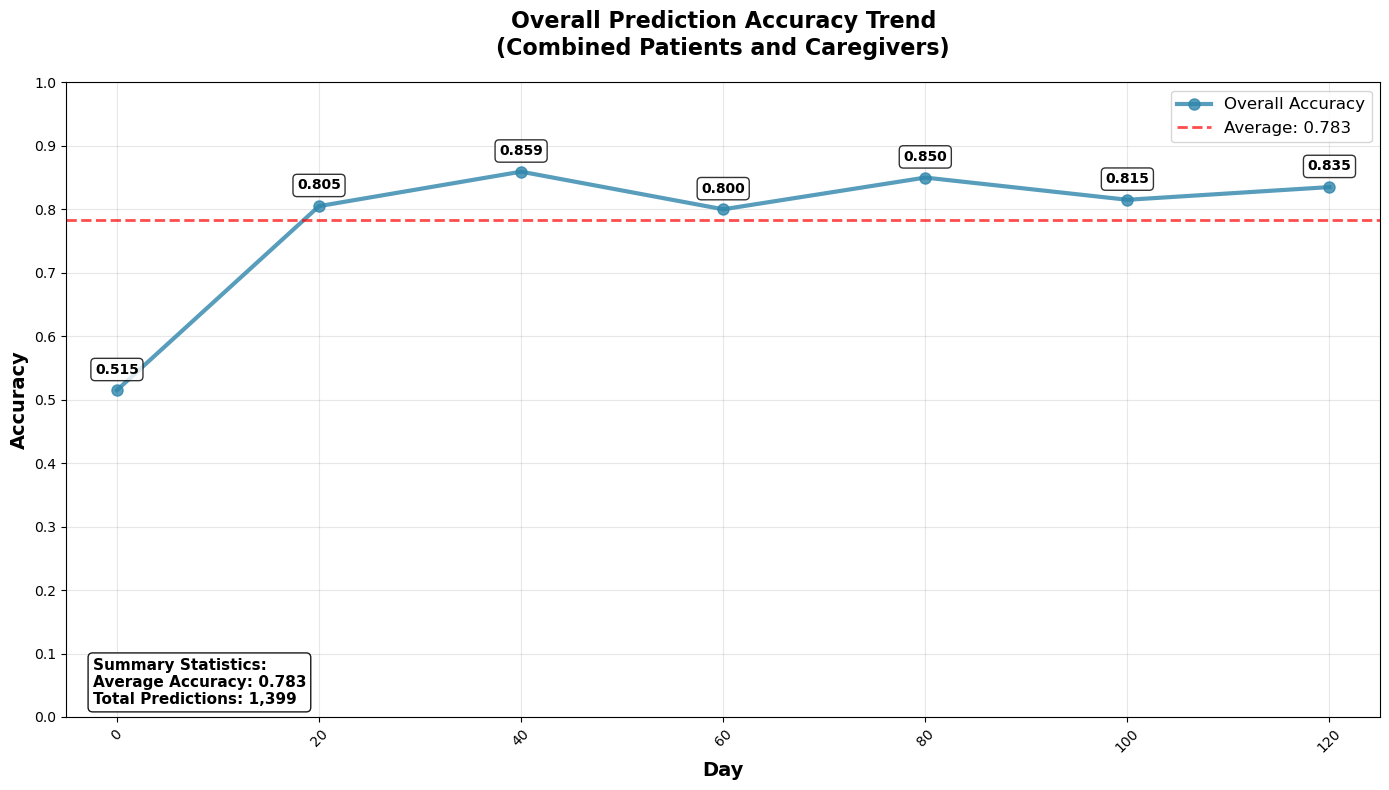


SUMMARY STATISTICS
Average Accuracy: 0.783 ± 0.120
Accuracy Range: 0.515 - 0.859
Total Predictions: 1,399
Total Correct Predictions: 1,095
Overall Accuracy Rate: 0.783


In [12]:
import json
from pathlib import Path
from typing import Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------
# Configuration
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
HF_REPO_ID = "nichenshun/rdmap_predictions_pre7days_activity"  
HF_CACHE_DIR = Path("./hf_cache")  

PREDICTIONS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

# Define analysis days (every 10 days from 0 to 120)
DAYS = [0, 20, 40, 60, 80, 100, 120]

# --------------------
# Load participants data
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_data.json must be a dict keyed by participant ID.")

# --------------------
# Helper Functions
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    """
    Get ground truth label for a participant on a specific day.
    Returns 1 if mood survey was completed, 0 if missing.
    """
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    """
    Extract decision and confidence from parsed model response.
    Returns dict with 'y_hat' (prediction) and 'confidence' values.
    """
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

# --------------------
# Compute Overall Accuracy (Combining Patients and Caregivers)
# --------------------
overall_accuracy_data = []

for day in DAYS:
    total_correct = 0
    total_predictions = 0
    
    # Process both patients and caregivers predictions
    for role in ["patients", "caregivers"]:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            continue

        # Count correct predictions for this role and day
        for pid, rec in preds_dict.items():
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Check if prediction is correct
            if y_hat == y_true:
                total_correct += 1
            total_predictions += 1

    # Calculate overall accuracy for this day
    if total_predictions > 0:
        accuracy = total_correct / total_predictions
    else:
        accuracy = np.nan

    overall_accuracy_data.append({
        'day': day,
        'accuracy': accuracy,
        'correct_predictions': total_correct,
        'total_predictions': total_predictions
    })

    print(f"[INFO] Day {day}: Overall Accuracy = {accuracy:.3f} ({total_correct}/{total_predictions} correct)")

# Convert to DataFrame
accuracy_df = pd.DataFrame(overall_accuracy_data)

# --------------------
# Print Detailed Accuracy Values
# --------------------
print("\n" + "="*80)
print("OVERALL ACCURACY VALUES (COMBINED PATIENTS AND CAREGIVERS)")
print("="*80)

print(f"\n{'Day':<6} {'Accuracy':<12} {'Correct/Total':<15} {'Percentage':<12}")
print("-" * 50)

for _, row in accuracy_df.iterrows():
    if not np.isnan(row['accuracy']):
        percentage = row['accuracy'] * 100
        print(f"{row['day']:<6} {row['accuracy']:.3f}{'':<8} {row['correct_predictions']}/{row['total_predictions']:<12} {percentage:.1f}%")
    else:
        print(f"{row['day']:<6} {'N/A':<12} {'N/A':<15} {'N/A':<12}")

# --------------------
# Plot Overall Accuracy Trend
# --------------------
def plot_overall_accuracy(accuracy_df):
    """
    Plot overall accuracy trend across all days with value annotations.
    """
    plt.figure(figsize=(14, 8))
    
    # Filter out days with no data
    valid_data = accuracy_df[~accuracy_df['accuracy'].isna()]
    
    # Plot the accuracy trend line
    plt.plot(valid_data['day'], valid_data['accuracy'], 
             marker='o', linewidth=3, markersize=8, 
             color='#2E86AB', alpha=0.8, label='Overall Accuracy')
    
    # Add value annotations for each point
    for _, row in valid_data.iterrows():
        plt.annotate(f'{row["accuracy"]:.3f}', 
                    (row['day'], row['accuracy']),
                    textcoords="offset points",
                    xytext=(0,12),
                    ha='center',
                    fontsize=10,
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Customize the plot
    plt.title('Overall Prediction Accuracy Trend\n(Combined Patients and Caregivers)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Day', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Set axis limits and ticks
    plt.xlim(-5, 125)
    plt.ylim(0, 1)
    plt.xticks(DAYS, rotation=45)
    plt.yticks(np.arange(0, 1.1, 0.1))
    
    # Add legend and statistics
    avg_accuracy = valid_data['accuracy'].mean()
    plt.axhline(y=avg_accuracy, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Average: {avg_accuracy:.3f}')
    
    plt.legend(loc='best', fontsize=12)
    
    # Add summary statistics as text
    stats_text = f'Summary Statistics:\nAverage Accuracy: {avg_accuracy:.3f}\nTotal Predictions: {valid_data["total_predictions"].sum():,}'
    plt.annotate(stats_text, xy=(0.02, 0.02), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9),
                fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Generate the plot
plot_overall_accuracy(accuracy_df)

# --------------------
# Print Summary Statistics
# --------------------
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

valid_data = accuracy_df[~accuracy_df['accuracy'].isna()]
if len(valid_data) > 0:
    avg_accuracy = valid_data['accuracy'].mean()
    std_accuracy = valid_data['accuracy'].std()
    min_accuracy = valid_data['accuracy'].min()
    max_accuracy = valid_data['accuracy'].max()
    total_predictions = valid_data['total_predictions'].sum()
    total_correct = valid_data['correct_predictions'].sum()
    
    print(f"Average Accuracy: {avg_accuracy:.3f} ± {std_accuracy:.3f}")
    print(f"Accuracy Range: {min_accuracy:.3f} - {max_accuracy:.3f}")
    print(f"Total Predictions: {total_predictions:,}")
    print(f"Total Correct Predictions: {total_correct:,}")
    print(f"Overall Accuracy Rate: {(total_correct/total_predictions):.3f}")
else:
    print("No valid data available for analysis.")